# Q2 — Which restaurants disagree the most? (pairwise)

Because the pairs rest on very different sample sizes, the biggest disagreers are listed
**per pair** (Google vs Tripadvisor, Google vs TheFork) and for the all-three set, rather
than pooled. This reproduces and extends the README's mandatory *"rating difference > 1
star"* query.

Each pair is drawn as a **dumbbell**: one row per restaurant, a brand-coloured dot per
platform on a shared star axis, joined by a grey bar whose length *is* the disagreement. This
beats a single |difference| bar because it also shows **which** platform is the outlier, where
each rating sits, the street (for franchises that the name alone can't place), and — via the
small review counts — whether the gap rests on real evidence or a single review.

We then ask the sharper question: which venues disagree *with enough reviews on both sides* to
be a real signal? The **robust** view re-ranks the Google–Tripadvisor pair with both
platforms gated at ≥100 reviews.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
# Shared Q2 helpers. The dumbbell puts one row per restaurant: a brand-coloured dot per
# platform on a shared star axis, joined by a grey bar whose *length* is the disagreement and
# whose dot *positions* show which platform is the outlier — more honest than a single |diff|
# bar. Horizontal orientation is deliberate (long names need the y-axis room). Streets are shown
# only for franchise names that are otherwise unplaceable ("Kfc"); the map locates the rest.
_FRANCHISES = {"kfc", "mcdonald's", "mcdonald", "burger king", "starbucks",
               "old wild west", "spontini", "roadhouse", "five guys"}


def _short(s, n=40):
    s = str(s)
    return s if len(s) <= n else s[: n - 1] + "…"


def _needs_street(name):
    return str(name).strip().lower() in _FRANCHISES


def _tick(rank, name, street):
    head = f"<b>{rank}.</b> {_short(name, 38)}" if rank else _short(name, 38)
    if _needs_street(name) and street is not None and not pd.isna(street):
        return f"{head}<br><span style='font-size:10px;color:#909296'>{_short(street, 28)}</span>"
    return head


def q2_dumbbell(df, platforms, title, *, top_n=12, show_counts=True, ranked=False):
    d = df.head(top_n).copy().reset_index(drop=True)
    d["rank"] = d.index + 1
    d = d[::-1].reset_index(drop=True)  # biggest gap on top
    rating = {p: (f"{p}_rating" if f"{p}_rating" in d else f"{p}_rating_5") for p in platforms}
    d["lbl"] = d["canonical_name"].map(lambda s: _short(s, 38))
    streets = d["canonical_street"] if "canonical_street" in d else [None] * len(d)
    d["tick"] = [_tick(r if ranked else None, n, s)
                 for r, n, s in zip(d["rank"], d["canonical_name"], streets)]
    fig = go.Figure()
    for _, r in d.iterrows():
        xs = [r[rating[p]] for p in platforms]
        fig.add_trace(go.Scatter(x=[min(xs), max(xs)], y=[r["lbl"], r["lbl"]], mode="lines",
            line=dict(color="#CED4DA", width=4), showlegend=False, hoverinfo="skip"))
    for p in platforms:
        fig.add_trace(go.Scatter(x=d[rating[p]], y=d["lbl"], mode="markers", name=p,
            marker=dict(size=14, color=PLATFORM_COLORS[p], line=dict(color="white", width=1))))
    if show_counts:
        for _, r in d.iterrows():
            for p in platforms:
                col = f"{p}_reviews"
                if col not in d:
                    continue
                nv = "—" if pd.isna(r[col]) else f"{int(r[col])}"
                fig.add_annotation(x=r[rating[p]], y=r["lbl"], text=f"<i>{nv}</i>",
                    showarrow=False, yshift=11, font=dict(size=9, color=PLATFORM_COLORS[p]))
        fig.add_annotation(xref="paper", yref="paper", x=0, y=1.045, xanchor="left", yanchor="bottom",
            showarrow=False, font=dict(size=11, color="#868E96"),
            text="<i>italic numbers next to each dot = that platform's review count</i>")
    fig.update_layout(template="plotly_white", height=max(520, 48 * len(d) + 190),
        margin=dict(l=310, r=40, t=96, b=150), title=title,
        xaxis=dict(title="rating (stars)", ticksuffix="★", range=[0.5, 5.2], dtick=0.5),
        legend=dict(orientation="h", yanchor="bottom", y=1.012, xanchor="right", x=1))
    fig.update_yaxes(tickmode="array", tickvals=d["lbl"], ticktext=d["tick"])
    return fig


def q2_caption(fig, text, y=-0.13):
    """A storytelling caption centred *below* the plot, clear of the axis title."""
    fig.add_annotation(xref="paper", yref="paper", x=0.5, y=y, xanchor="center", yanchor="top",
        align="center", showarrow=False, font=dict(size=12.5, color="#495057"), text=text)


In [3]:
q2_gta = publish(run(queries.q2_top_pair("google", "tripadvisor", top_n=20, min_diff=1.0)),
                 "q2_top_google_vs_tripadvisor",
                 "Q2 — Largest Google vs Tripadvisor rating gaps (>1 star).")
q2_gta

,canonical_name,canonical_street,google_rating,tripadvisor_rating,abs_diff,google_reviews,tripadvisor_reviews
0,SUSHI NIKKEI Duomo San Babila Milano - Restaur...,Via Colonnetta,4.7,1.0,3.7,87,1
1,Villa,Piazza Edoardo Ferravilla,4.6,1.0,3.6,70,1
2,Osteria San Giovanni - Ristorante Pugliese,Viale Monza,4.6,1.0,3.6,101,1
3,Silia Pizza al Trancio,Via Giambellino,4.5,1.0,3.5,274,1
4,Poke House - Nirone,Via Nirone,4.5,1.0,3.5,329,2
5,Il Buon Pane,Via Giovanni Battista Fauchè,4.5,1.0,3.5,80,1
6,Pizzeria S. Stefano,Viale Monza,4.5,1.0,3.5,152,1
7,Vino,Via Pier Lombardo,4.4,1.0,3.4,314,2
8,Vibes cocktail bar,Ripa di Porta Ticinese,4.4,1.0,3.4,258,2
9,Cento Caffè caffetteria,Piazza Rosa Scolari,4.4,1.0,3.4,511,1


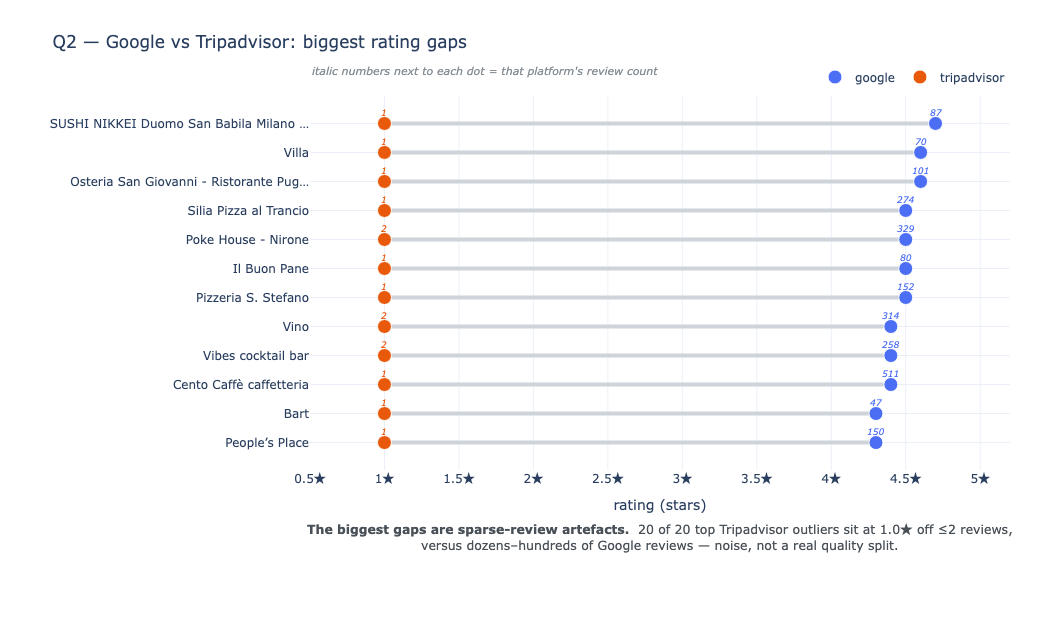

In [4]:
# Headline pair: Google vs Tripadvisor (largest sample, widest gaps). Top 12 so the rows
# breathe. The dumbbell exposes *why* the gaps are so large — nearly every Tripadvisor outlier
# sits at exactly 1.0★ off a single review, while Google rests on dozens to hundreds.
fig = q2_dumbbell(q2_gta, ["google", "tripadvisor"],
                  "Q2 — Google vs Tripadvisor: biggest rating gaps", top_n=12)
_thin = int((q2_gta["tripadvisor_reviews"] <= 2).sum())
q2_caption(fig, "<b>The biggest gaps are sparse-review artefacts.</b>  "
    f"{_thin} of {len(q2_gta)} top Tripadvisor outliers sit at 1.0★ off ≤2 reviews,<br>"
    "versus dozens–hundreds of Google reviews — noise, not a real quality split.")
fig.show()

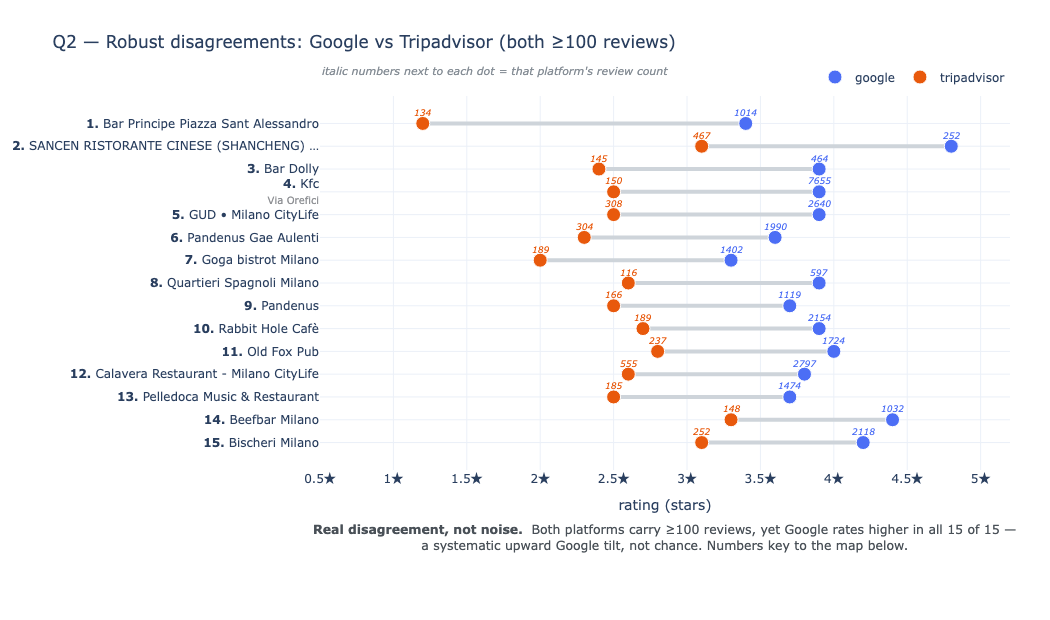

In [5]:
# The sharper question: which venues disagree with *enough evidence on both sides* to be a
# real signal? Gate both platforms at the "established" volume (>=100 reviews) and re-rank —
# these are the genuinely interesting disagreements, mapped just below.
ROBUST_REVIEWS = 100
q2_robust = publish(
    run(queries.q2_top_pair("google", "tripadvisor", top_n=15, min_diff=1.0,
                            min_reviews_a=ROBUST_REVIEWS, min_reviews_b=ROBUST_REVIEWS)),
    "q2_robust_google_vs_tripadvisor",
    "Q2 — Largest Google vs Tripadvisor gaps where both platforms have >=100 reviews.")
fig = q2_dumbbell(q2_robust, ["google", "tripadvisor"],
    f"Q2 — Robust disagreements: Google vs Tripadvisor (both ≥{ROBUST_REVIEWS} reviews)",
    top_n=15, ranked=True)
_ghi = int((q2_robust["google_rating"] > q2_robust["tripadvisor_rating"]).sum())
q2_caption(fig, "<b>Real disagreement, not noise.</b>  Both platforms carry ≥100 reviews, yet Google rates "
    f"higher in all {_ghi} of {len(q2_robust)} —<br>a systematic upward Google tilt, not chance. "
    "Numbers key to the map below.")
fig.show()

In [6]:
q2_gtf = publish(run(queries.q2_top_pair("google", "thefork", top_n=20, min_diff=1.0)),
                 "q2_top_google_vs_thefork",
                 "Q2 — Largest Google vs TheFork rating gaps (>1 star).")
q2_gtf

,canonical_name,canonical_street,google_rating,thefork_rating,abs_diff,google_reviews,thefork_reviews
0,Tasty Bite Cucina Indiana,Via Giuseppe Ripamonti,4.8,1.00,3.80,37,<NA>
1,Mia Poke,Via Giovita Scalvini,4.4,1.65,2.75,43,3
2,Archie’s - Comida Peruviana,Viale Monza,4.4,2.15,2.25,204,5
3,Il francolino Pizzeria / Bar,Via Giuseppe Chiostergi,4.5,3.00,1.50,10,<NA>
4,Solar Grill,Via Piero della Francesca,2.9,4.20,1.30,19,118
5,Spadari Restaurant,Via Spadari,2.8,3.90,1.10,815,6
6,Benza,Via Teodosio,3.9,2.85,1.05,203,191


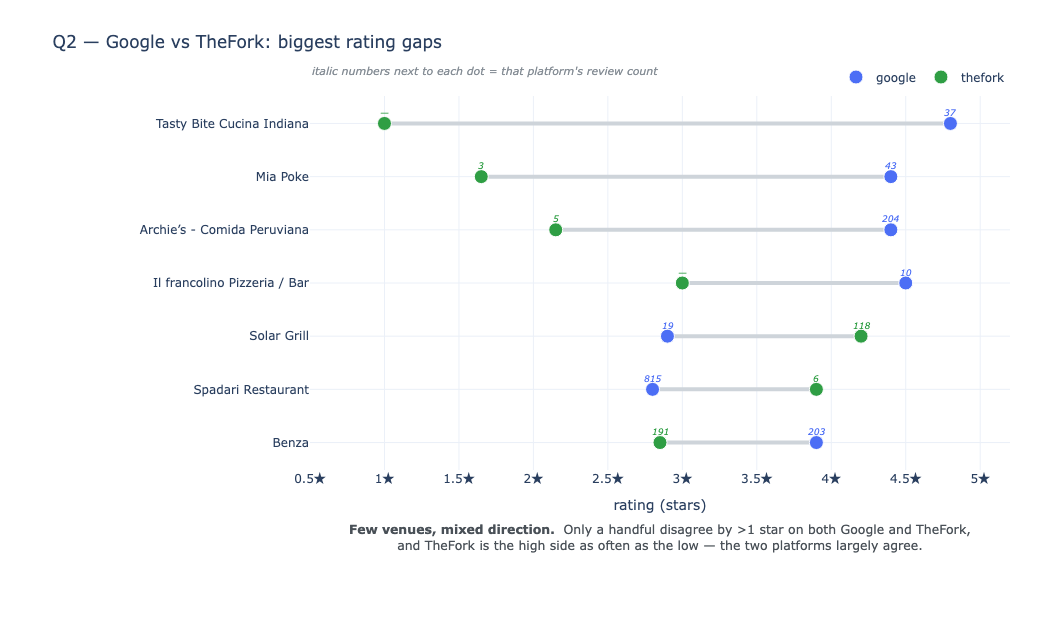

In [7]:
# Google vs TheFork: only a handful of venues disagree by >1 star and the direction is mixed
# (TheFork is the high side as often as the low) — the two platforms largely agree.
fig = q2_dumbbell(q2_gtf, ["google", "thefork"],
                  "Q2 — Google vs TheFork: biggest rating gaps", top_n=12)
q2_caption(fig, "<b>Few venues, mixed direction.</b>  Only a handful disagree by >1 star on both Google "
    "and TheFork,<br>and TheFork is the high side as often as the low — the two platforms largely agree.")
fig.show()

In [8]:
q2_all = publish(run(queries.q2_top_all_three(top_n=20)), "q2_top_all_three",
                 "Q2 — Largest full-range disagreements among all-three-platform venues.")
q2_all

,canonical_name,canonical_street,google_rating_5,tripadvisor_rating_5,thefork_rating_5,rating_range_5
0,Ristorante Pesce D'amare,Via Pavia,4.3,2.0,4.35,2.35
1,Pizza Garage,Viale Carlo Troya,4.1,2.1,4.40,2.30
2,SANCEN RISTORANTE CINESE (SHANCHENG) 山城小灶,Via Vigevano,4.8,3.1,5.00,1.90
3,Salotto Brera,Via Montebello,4.4,2.5,4.15,1.90
4,Osteria delle Coppelle Milano,Via Solferino,3.5,2.4,4.20,1.80
5,Sandì,Via Francesco Hayez,4.7,3.0,4.65,1.70
6,Trattoria dell'Arco,Via L. Cagnola,4.7,3.0,4.35,1.70
7,Gòodurie Soresina,Via Alessio di Tocqueville,4.3,2.6,4.25,1.70
8,Ci Sta - Buenos Aires,Via Federico Ozanam,4.3,2.8,4.40,1.60
9,La Jungle De Plein - Bistrot & Garden,Via Daniele Manin,4.6,3.0,4.00,1.60


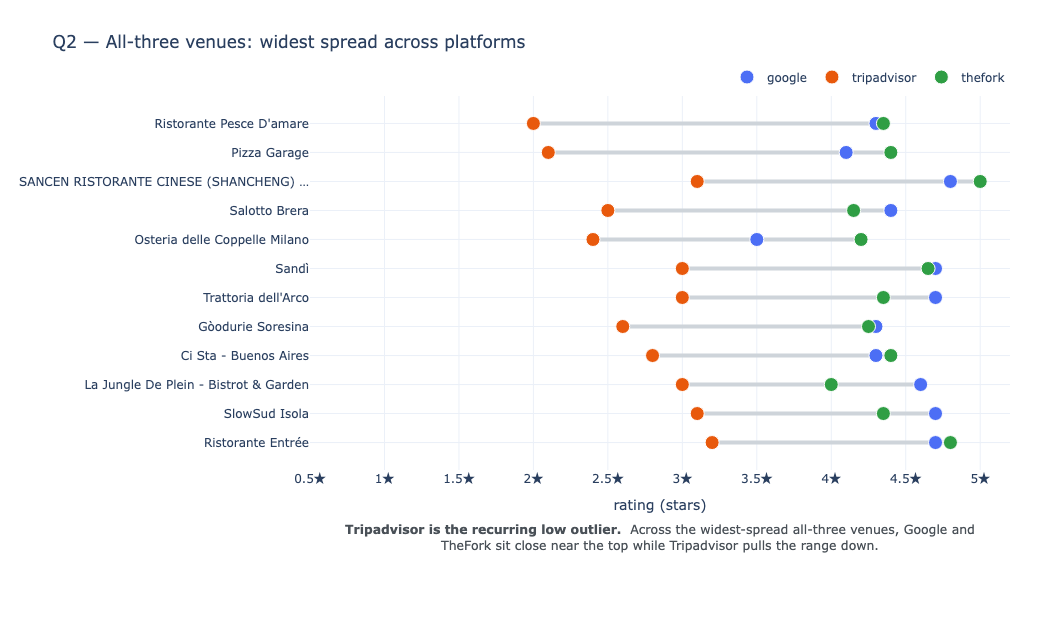

In [9]:
# All-three venues, ranked by full-range spread (max − min across platforms). Top 12 for room.
# Here every platform has a real rating, so the spread is genuine: Tripadvisor is the recurring
# low outlier while Google and TheFork track each other near the top.
fig = q2_dumbbell(q2_all, ["google", "tripadvisor", "thefork"],
                  "Q2 — All-three venues: widest spread across platforms", top_n=12, show_counts=False)
q2_caption(fig, "<b>Tripadvisor is the recurring low outlier.</b>  Across the widest-spread all-three "
    "venues, Google and<br>TheFork sit close near the top while Tripadvisor pulls the range down.")
fig.show()

**Answer (Q2):** Ranked purely by gap size, the worst disagreements are almost entirely
**sparse-review artefacts** — the top Tripadvisor outliers sit at exactly 1.0★ off a
single review, against dozens to hundreds on Google. Once both platforms are required to have
≥100 reviews (the **robust** view), a cleaner finding emerges: ~15 well-reviewed venues
still differ by >1 star, and on every one **Google rates higher than Tripadvisor** — a
systematic upward Google tilt, not random noise (consistent with Q1/Q5).
`q2_top_google_vs_thefork` is much shorter, with mixed direction, and almost nothing survives
the ≥100-review gate — those two platforms largely agree. Finally, the **all-three** view
(every platform present) gives the genuine three-way spreads — a set that barely overlaps the
Google–Tripadvisor disagreers (one venue in common) — where Tripadvisor is again the recurring
low outlier while Google and TheFork track each other near the top.